# Análisis exploratorio de datos


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from utils2 import get_regression_metrics

## Paso 1: Definición del problema

> ¿cuál va a ser la prima (coste) que debe asumir cada uno de los clientes de la compañía de seguros 4Geeks Insurance S.L?

## Paso 2: Recopilación de datos

> Dataset de [medical_insurance_cost.csv](https://breathecode.herokuapp.com/asset/internal-link?id=929&path=medical_insurance_cost.csv)

### Importamos los datos y creamos el DataFrame

In [2]:
df = pd.read_csv("/workspaces/CarlosRestrepo-machine-learning-python/data/raw/medical_insurance_cost.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Paso 3: Análisis Descriptivo

In [3]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


### Observaciones:

> ### Observaciones:
> - Existen un total de 1338 filas y 7 columnas, entre las cuales encontramos el target o clase a predecir, `charges`.
> - Ninguna variable contiene valores nulos.
> - Los datos cuentan con 4 características numéricas y 3 características categóricas.

## Paso 4: Limpieza de Datos

### Limpieza de datos: Eliminar duplicados

In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Limpieza de datos: Eliminar información irrelevante

> ### Conclusión:
>
> Todas las características son imprescindibles para realizar una predicción.

## Paso 5: Análisis de Variables

### Análisis de Variables Univariante

#### Análisis de Variables Univariante Categóricas

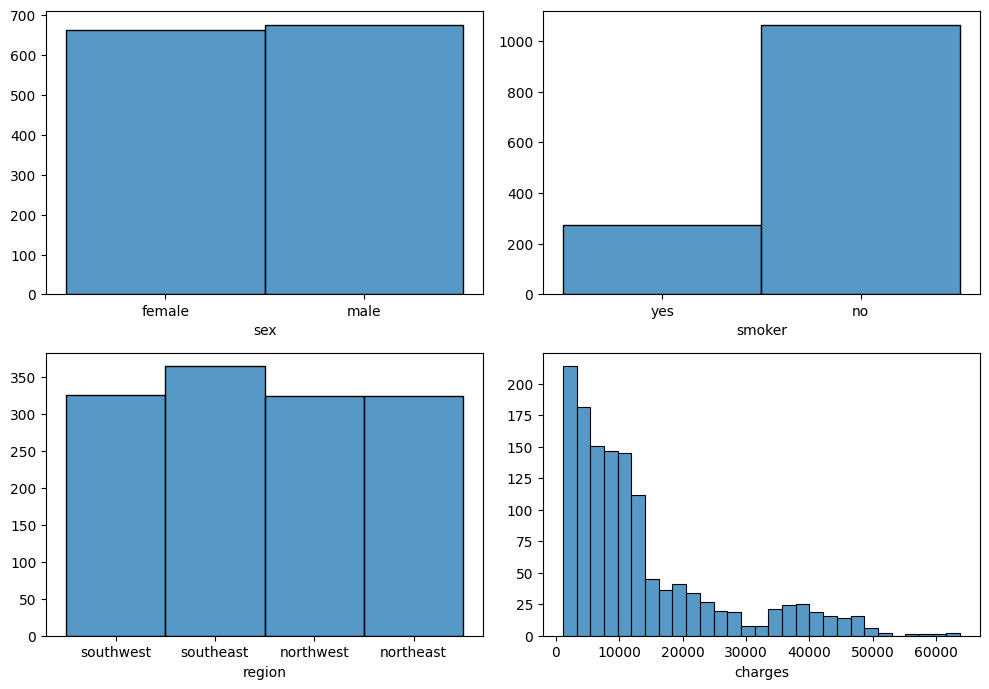

In [8]:
fig, axis = plt.subplots(2, 2, figsize=(10, 7))

sns.histplot(ax=axis[0, 0], data=df, x="sex").set(ylabel=None)
sns.histplot(ax=axis[0, 1], data=df, x="smoker").set(ylabel=None)
sns.histplot(ax=axis[1, 0], data=df, x="region").set(ylabel=None)
sns.histplot(ax=axis[1, 1], data=df, x="charges").set(ylabel=None)

plt.tight_layout()


> #### Observaciones
>
> - **sex**: La muestra de genero representa un balance parecido en el numero de hombres como de mujeres.
> - **smoker**: Más de 1000 clientes son no fumadores antes los mas de 200 clientes que si
> - **region**: Hay una muestra proporcionada ante las diferentes regiones de muestreo.
> - **charges**: La mayoría de los clientes de 4Geeks Insurance S.L tienen una prima de 1000.

#### Análisis de Variables Univariante Numéricas

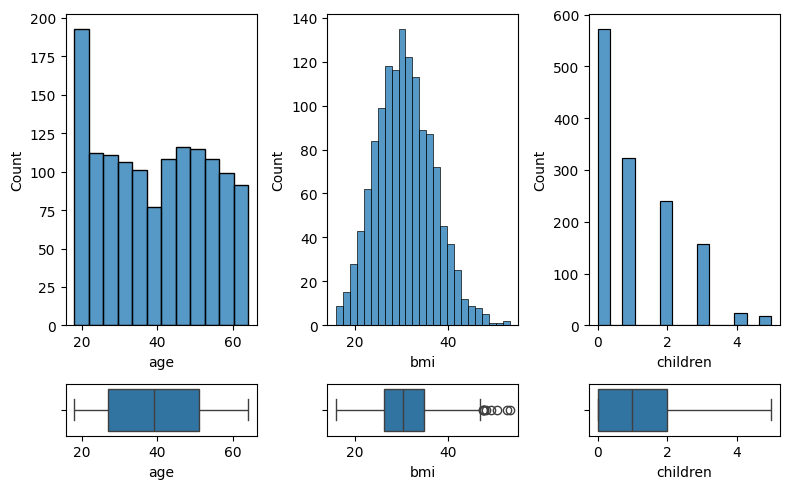

In [9]:
fig, axis = plt.subplots(2, 3, figsize=(8, 5), gridspec_kw={'height_ratios': [6, 1]})

# Crear una figura múltiple con histogramas y diagramas de caja
sns.histplot(ax=axis[0, 0], data=df, x="age")
sns.boxplot(ax=axis[1, 0], data=df, x="age")

sns.histplot(ax=axis[0, 1], data=df, x="bmi")
sns.boxplot(ax=axis[1, 1], data=df, x="bmi")

sns.histplot(ax=axis[0, 2], data=df, x="children")
sns.boxplot(ax=axis[1, 2], data=df, x="children")

plt.tight_layout()


> #### Observaciones:
>
> - La combinación de los dos gráficos nos permite conocer las distribuciones y sus características estadísticas.
> - De la visualización resultante podemos tener en claro que ambas bmi cuyenta con valores atípicos.

### Análisis de Variables Multivariante

#### Análisis numérico-numérico

##### charges - (age, bmi, children)
Primero analizamos el target frente a las características numéricas:

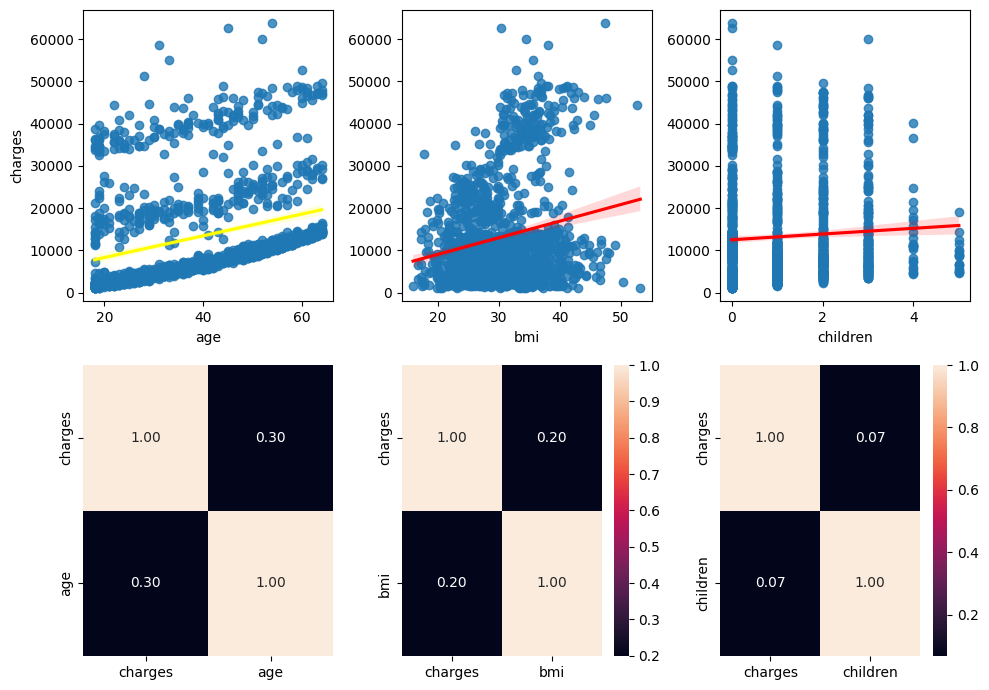

In [10]:
# Generamos las correlaciones
corr_charges_age = df[["charges", "age"]].corr()
corr_charges_bmi = df[["charges", "bmi"]].corr()
corr_charges_children = df[["charges", "children"]].corr()

# Crear un diagrama de dispersión múltiple
fig, axis = plt.subplots(2, 3, figsize=(10, 7))

sns.regplot(ax=axis[0, 0], data=df, x="age", y="charges", line_kws={'color': 'yellow'})
sns.heatmap(ax=axis[1, 0], data=corr_charges_age, annot=True, fmt=".2f", cbar=False)

sns.regplot(ax=axis[0, 1], data=df, x="bmi", y="charges", line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 1], data=corr_charges_bmi, annot=True, fmt=".2f")

sns.regplot(ax=axis[0, 2], data=df, x="children", y="charges", line_kws={'color': 'red'}).set(ylabel=None)
sns.heatmap(ax=axis[1, 2], data=corr_charges_children, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()

> ##### Observaciones
>
> - `charges` tiene una relación directa con `age` y `bmi`.
> - `children` no tiene mucha relacion, no afecta demasiado con `charges`

#### Análisis categórico-numérico

##### charges - (sex, smoker, region)

Primero analizamos el target frente a las características categóricas, una a una. 

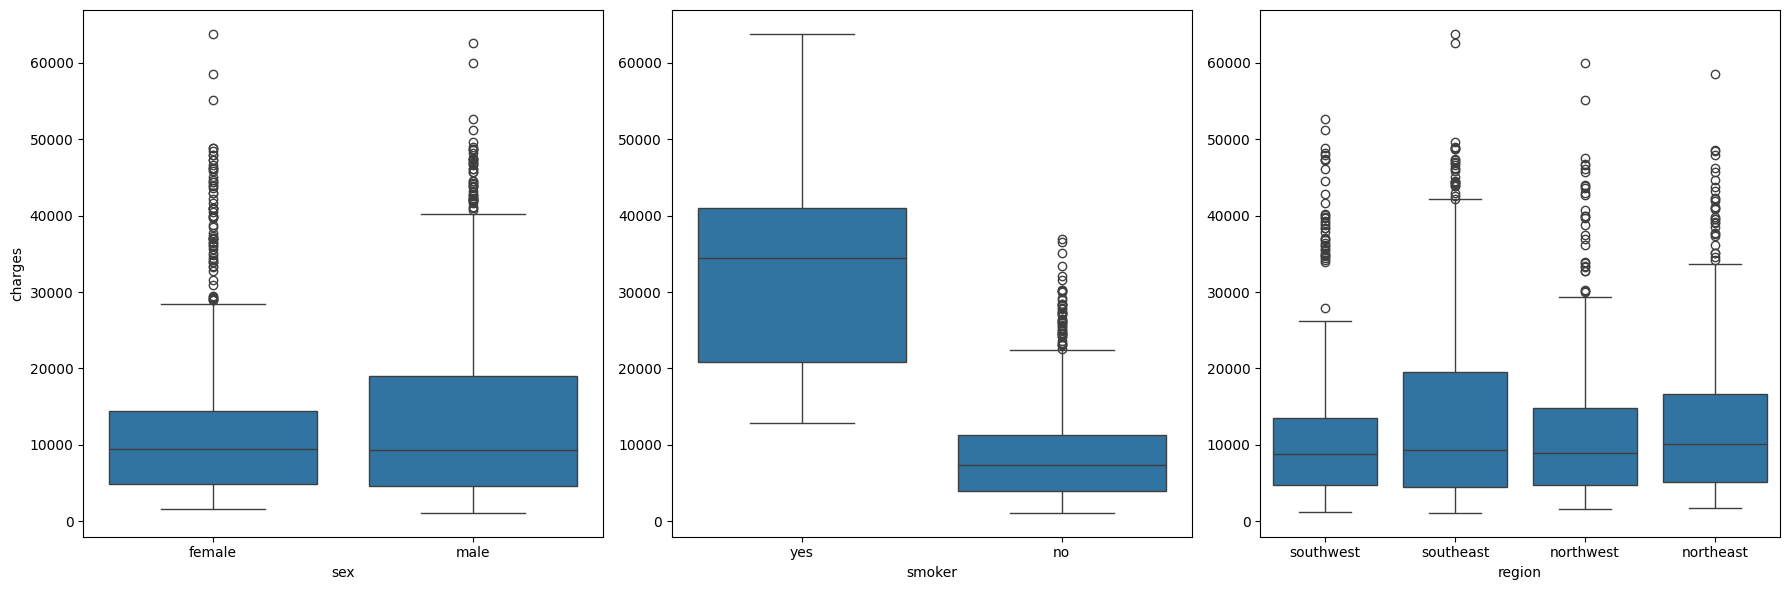

In [11]:
fig, axis = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(ax=axis[0], data=df, x="sex", y="charges")
sns.boxplot(ax=axis[1], data=df, x="smoker", y="charges").set(ylabel=None)
sns.boxplot(ax=axis[2], data=df, x="region", y="charges").set(ylabel=None)

plt.tight_layout()
plt.show()

##### Observaciónes
Smoker (Fumador): Es la variable más influyente. Los fumadores (yes) tienen una mediana de costes dramáticamente más alta y una dispersión mucho mayor en comparación con los no fumadores (no). Esta es la variable más crítica para la predicción.

Sex (Género): La mediana y la distribución de costes son muy similares entre hombres (male) y mujeres (female). Esto sugiere que el género, por sí solo, tendrá una influencia predictiva baja en el coste del seguro.

Region (Región): Las cuatro regiones tienen distribuciones de costes relativamente similares, aunque southeast parece tener una mediana ligeramente más alta que las demás. La diferencia entre regiones es mucho menor que la diferencia observada por el estado de fumador.

Conclusión: El estado de fumador es el principal impulsor de la variación en la prima (charges).

##### Análisis de correlaciones

Creo una copia del dataframe para trabajar con las columnas categoricas factorizadas.

In [12]:
# Creo columnas numéricas para las variables categóricas
df2 =df.copy()
df2["sex_n"] = pd.factorize(df2["sex"])[0]
df2["smoker_n"] = pd.factorize(df2["smoker"])[0]
df2["region_n"] = pd.factorize(df2["region"])[0]

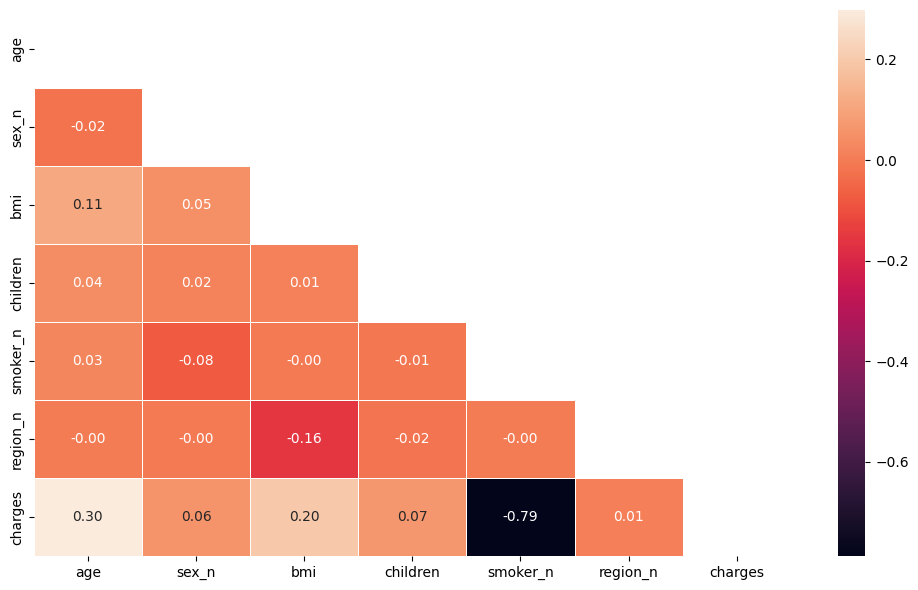

In [13]:
corr = df2[["age", "sex_n", "bmi", "children", "smoker_n", "region_n", "charges"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 6))
sns.heatmap(corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")

plt.tight_layout()
plt.show()

> ##### Observaciones:
>
> - El análisis de correlaciones refleja una fuerte relación directa entre la edad (`age`) del cliente y la prima a pagar.
> - Además, se aprecia una fuerte relación negativa entre los clientes fumadores `smoker_n` y la prima a pagar.

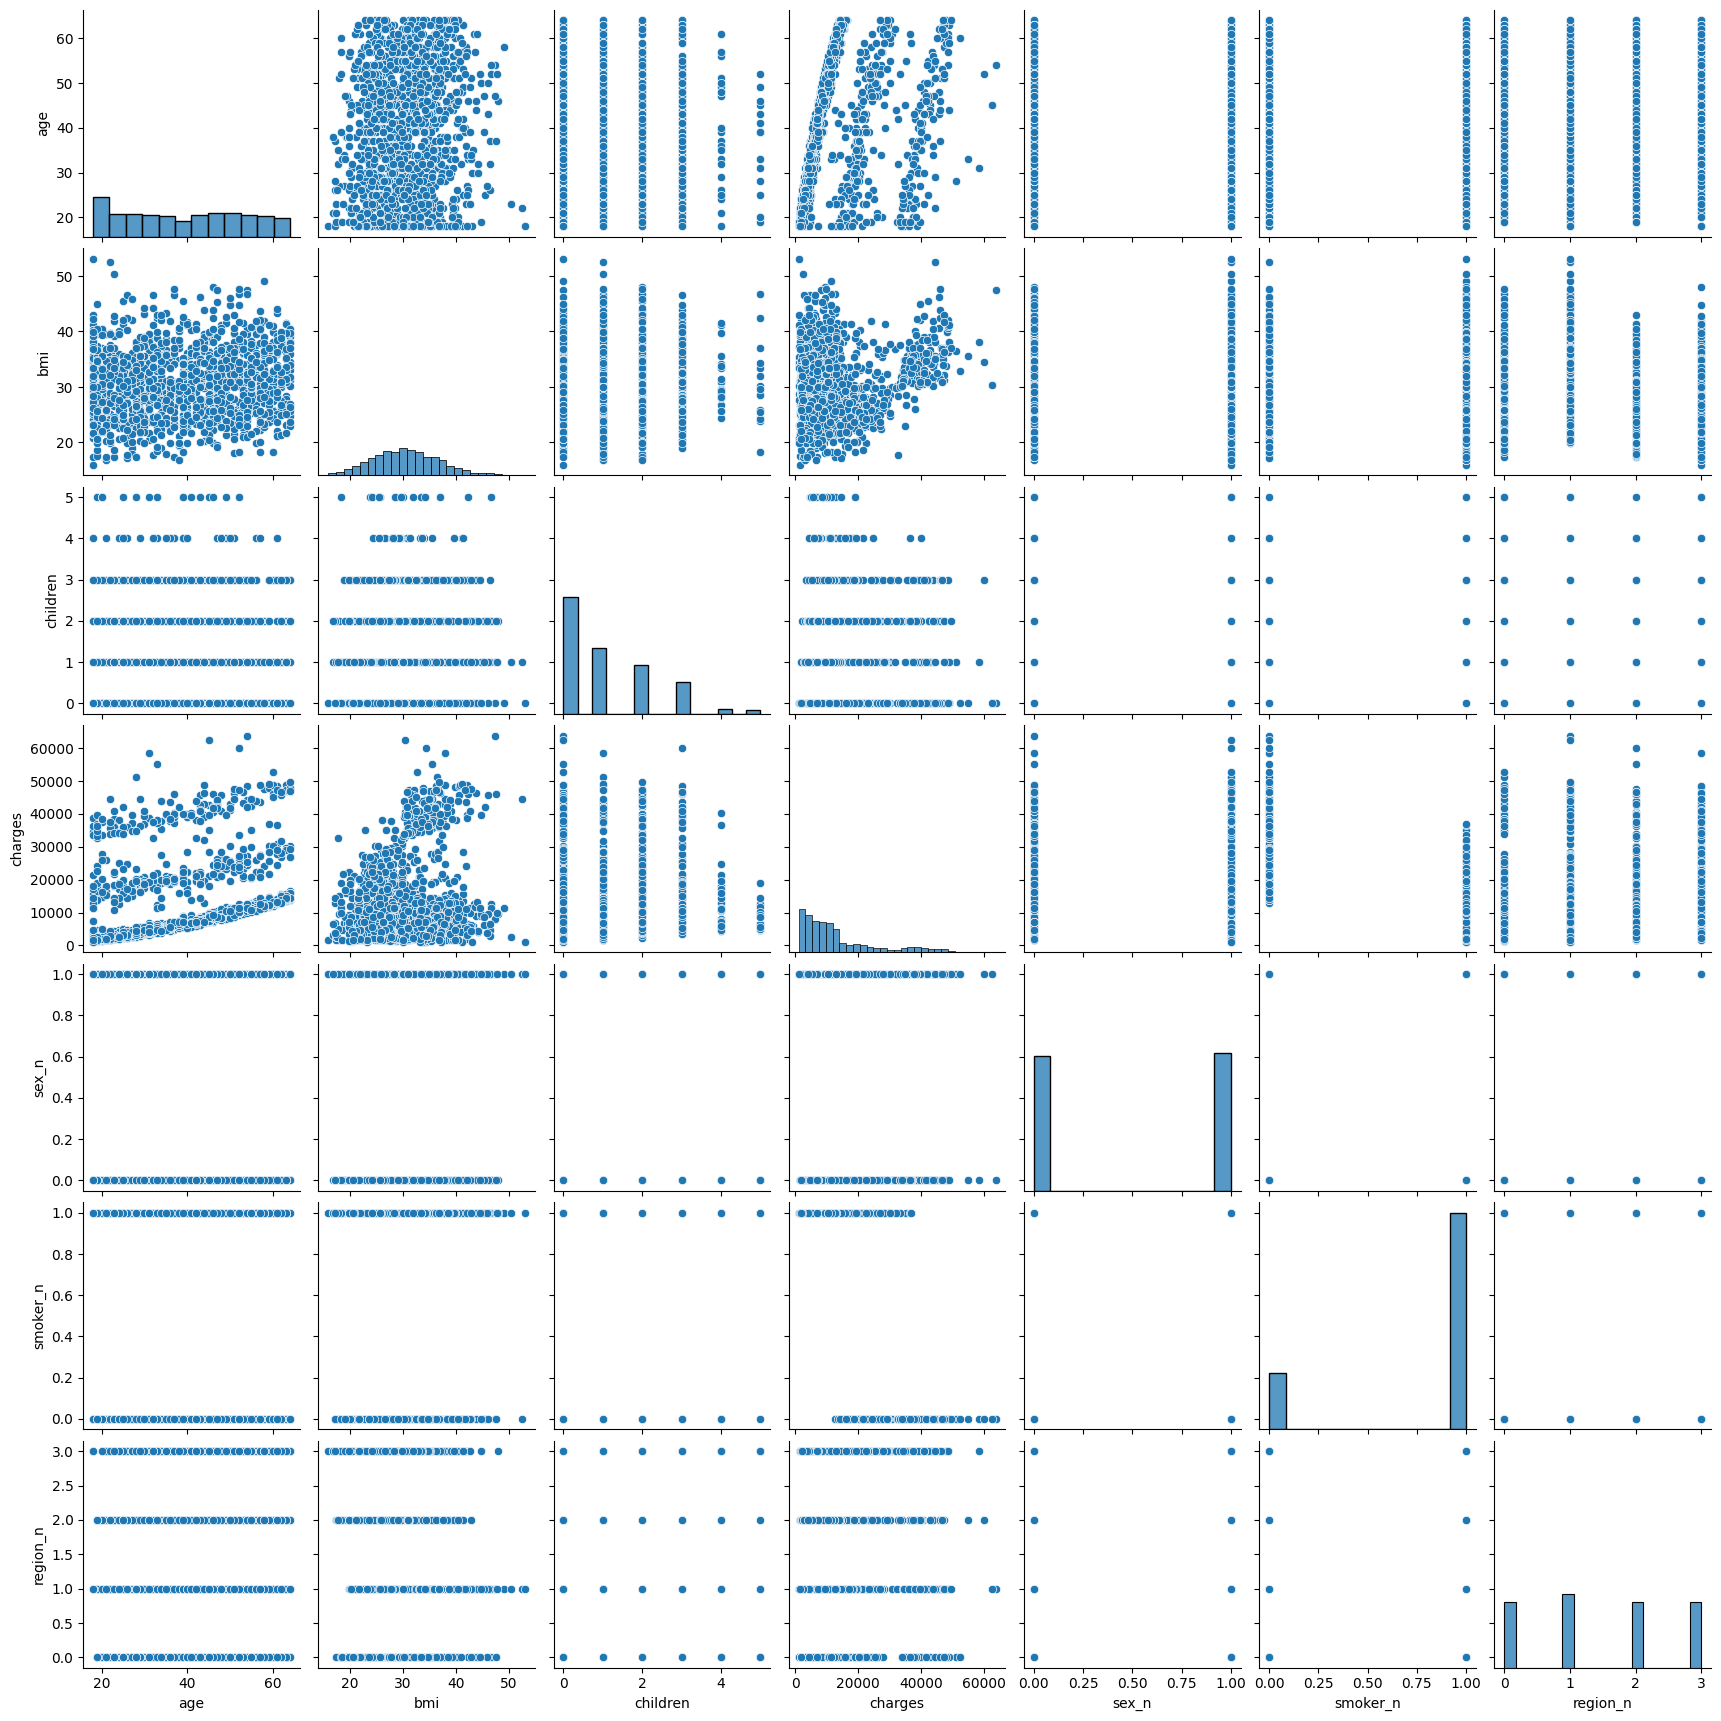

In [14]:
sns.pairplot(data=df2)

## Paso 6: Ingeniería de características

#### Análisis de outliers

**Outliers: Análisis descriptivo**

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1337.0,39.222139,14.044333,18.0000,27.000,39.0000,51.00000,64.00000
bmi,1337.0,30.663452,6.100468,15.9600,26.290,30.4000,34.70000,53.13000
children,1337.0,1.095737,1.205571,0.0000,0.000,1.0000,2.00000,5.00000
charges,1337.0,13279.121487,12110.359656,1121.8739,4746.344,9386.1613,16657.71745,63770.42801


#### Observaciones:
>
> La columna `bmi` el indice de masa corporal tiene outliers asi como `charges`.

**Outliers: Visualización**

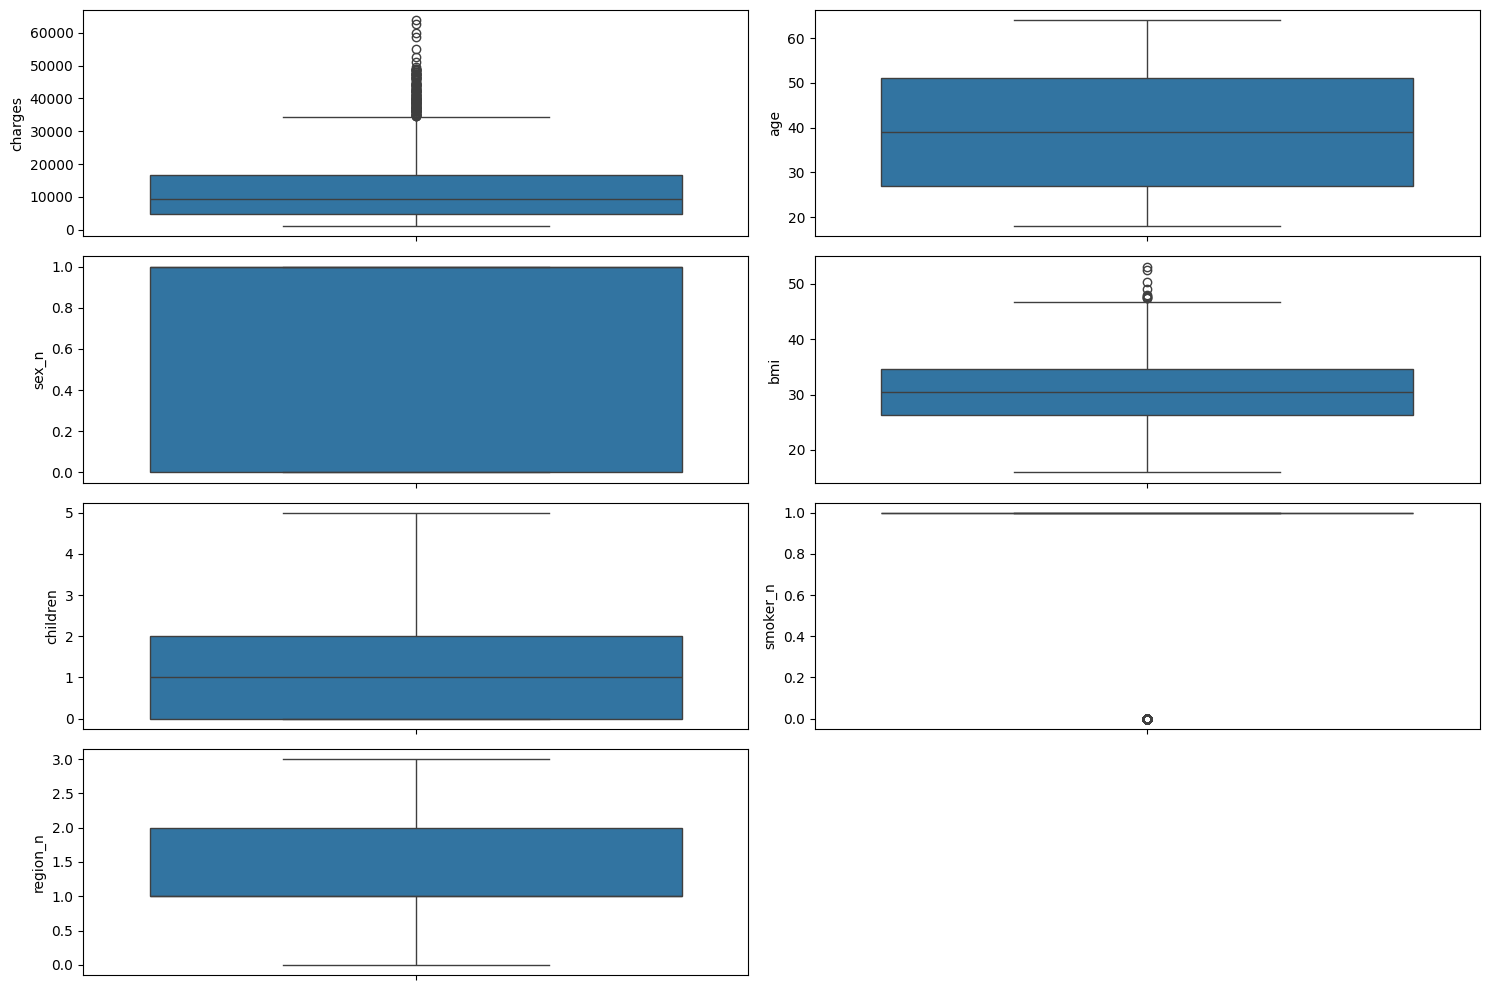

In [16]:
fig, axis = plt.subplots(4, 2, figsize=(15, 10))

sns.boxplot(ax=axis[0, 0], data=df2, y="charges")
sns.boxplot(ax=axis[0, 1], data=df2, y="age")
sns.boxplot(ax=axis[1, 0], data=df2, y="sex_n")
sns.boxplot(ax=axis[1, 1], data=df2, y="bmi")
sns.boxplot(ax=axis[2, 0], data=df2, y="children")
sns.boxplot(ax=axis[2, 1], data=df2, y="smoker_n")
sns.boxplot(ax=axis[3, 0], data=df2, y="region_n")
fig.delaxes(axis[3, 1])

plt.tight_layout()
plt.show()

#### Observaciones
>
> - Claramente nuestro `charges` tienen outliers por encima de los 40000.
> - `bmi` el indice de masa corporal presenta outliers superiores sobre el 45.

#### Análisis de outliers

In [17]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


#### Observaciones:
> - Se puede apreciar como charges teien un max muy superior al percentil 75%, por lo que voy a proceder a calcular su percentil 0.99

In [18]:
#I created a dictionary with the necessary calculated percentiles for every column needed.
quantile_columns = {'charges':df['charges'].quantile(0.99),
                  'bmi':df['bmi'].quantile(0.99)}

#I combined conditions to accelerate the coding process.
filter_combined_condition = ((df['charges'] <= quantile_columns['charges']) &
                              (df['bmi'] <= quantile_columns['bmi'])
                                )
#Apply the filter to the DataFrame
df = df[filter_combined_condition]

#### Análisis de valores faltantes

In [19]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

##### Observaciones:
> - No hay valores nulos

## Paso 7: Split (dos métodos o enfoques)

In [20]:
#Dividimos el conjunto de datos en muestras de train y test
X = df.drop("charges", axis=1)
y = df["charges"]


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=18)

Codificación de variables categoricas

Codificamos la columna `region`, mapeamos `sex` y `smoker`, las guardamos con un nuevo nombre que represente que ahora son numerales, `sex_n`, `smoker_n`.

In [21]:
#Aplicar One-Hot Encoding a 'region'
X_train_encoded = pd.get_dummies(X_train, columns=['region'])
X_test_encoded = pd.get_dummies(X_test, columns=['region'])

# Mapeo binario para 'sex' y 'smoker' (Label Encoding)
X_train_encoded['sex_n'] = X_train_encoded['sex'].apply(lambda x: 1 if x == 'male' else 0)
X_train_encoded['smoker_n'] = X_train_encoded['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

X_test_encoded['sex_n'] = X_test_encoded['sex'].apply(lambda x: 1 if x == 'male' else 0)
X_test_encoded['smoker_n'] = X_test_encoded['smoker'].apply(lambda x: 1 if x == 'yes' else 0)

X_train_encoded.drop(['sex', 'smoker'], axis=1, inplace=True)
X_test_encoded.drop(['sex', 'smoker'], axis=1, inplace=True)

- Procedemos a borrar las variables categoricas `sex` y `smoker`

### Realizamos el split

## Paso 8: Scaling & Encoding

### Scaling - Escalado de valores

#### Normalización

##### Realizar el escalando con el dataset dividido

Paso 1: Solo con el conjunto de Entrenamiento
Calculas la media ($\mu$) y la desviación estándar ($\sigma$) SOLO con los datos de entrenamiento:

In [22]:
num_variables = ["age", "bmi", "children", "region_northeast", "region_northwest", 
                 "region_southeast", "region_southwest", "sex_n", "smoker_n",]
norm_scaler = StandardScaler()
norm_scaler.fit(X_train_encoded[num_variables]) # Calcula media y std SOLO en train

,copy,True
,with_mean,True
,with_std,True


In [23]:
#TRANSFORM en X_train y X_test
X_train_encoded[num_variables] = norm_scaler.transform(X_train_encoded[num_variables])
X_test_encoded[num_variables] = norm_scaler.transform(X_test_encoded[num_variables])

#### Escalado Mínimo-Máximo

In [24]:
# Lista de variables a escalar (SOLO las numéricas/codificadas)
num_variables_escalar = [
    "age", "bmi", "children", 
    "sex_n", "smoker_n", 
    "region_northwest", "region_southeast", "region_southwest" 
]

minmax_scaler = MinMaxScaler()

minmax_scaler.fit(X_train_encoded[num_variables_escalar]) 

X_train_encoded[num_variables_escalar] = minmax_scaler.transform(X_train_encoded[num_variables_escalar])
X_test_encoded[num_variables_escalar] = minmax_scaler.transform(X_test_encoded[num_variables_escalar])


Verificar que los datos están ahora en el rango [0, 1] revisando las estadísticas de las columnas.

In [25]:
X_train_encoded.describe()

,age,bmi,children,region_northeast,region_northwest,region_southeast,region_southwest,sex_n,smoker_n
count,1048.000000,1048.000000,1048.000000,1.048000e+03,1048.000000,1048.000000,1048.000000,1048.000000,1048.000000
mean,0.458160,0.476082,0.214122,-2.033996e-17,0.244275,0.250954,0.255725,0.512405,0.200382
std,0.307402,0.192433,0.235102,1.000477e+00,0.429862,0.433769,0.436476,0.500085,0.400477
min,0.000000,0.000000,0.000000,-5.758812e-01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.173913,0.335214,0.000000,-5.758812e-01,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.456522,0.470212,0.200000,-5.758812e-01,0.000000,0.000000,0.000000,1.000000,0.000000
75%,0.717391,0.608862,0.400000,-5.758812e-01,0.000000,1.000000,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.736469e+00,1.000000,1.000000,1.000000,1.000000,1.000000


## Paso 9: Selección de características

In [26]:
selection_model = SelectKBest(f_regression, k=5)
# Con un valor de k=5 queremos decir implícitamente que queremos eliminar 2 características del conjunto de datos

selection_model.fit(X_train_encoded, y_train)

# Aplico el modelo a los datos X_train_encoded y X_test_encoded
selection_model_transform_train = selection_model.transform(X_train_encoded)
selection_model_transform_test = selection_model.transform(X_test_encoded)

# Obtener los índices de las columnas seleccionadas
ix = selection_model.get_support()

# Genero los dataframes usando los nombres de columna del DF codificado
X_train_sel = pd.DataFrame(selection_model_transform_train, 
                           columns=X_train_encoded.columns[ix]) # <-- Usar X_train_encoded.columns
X_test_sel = pd.DataFrame(selection_model_transform_test, 
                          columns=X_test_encoded.columns[ix]) # <-- Usar X_test_encoded.columns

X_train_sel.head()

,age,bmi,children,region_southwest,smoker_n
0,0.673913,0.542317,0.6,0.0,0.0
1,0.021739,0.386326,0.0,1.0,0.0
2,0.260870,0.495851,0.6,1.0,0.0
3,0.130435,0.660471,0.0,0.0,0.0
4,0.630435,0.393960,0.0,0.0,1.0


## Modelo de Regresión Lineal

In [27]:
# Modelo
lr_model = LinearRegression()

# Entrenamiento
lr_model.fit(X_train_encoded, y_train)

# Predicción
lr_y_pred_train = lr_model.predict(X_train_encoded)
lr_y_pred_test = lr_model.predict(X_test_encoded)

# Métricas
get_regression_metrics(lr_y_pred_test, y_test, lr_y_pred_train, y_train)

,R2,MAE,MAPE,MSE,RMSE
Train set,0.741608,2547.244412,41.858735,3.422300e+07,5850.043127
Test set,0.754756,2499.043522,42.560425,2.930775e+07,5413.663208
Difference,0.013149,-48.200890,0.701690,-4.915255e+06,-436.379918


> - Se puede observar que el modelo no tiene overfitting, con una presición R2 de 0.741608.
> - El error absoluto medio (MAE) significa que mi predicción se equivoca por caso 2500

In [28]:
ridge_model = Ridge(alpha=0.0001,
                    max_iter=5000,
                    random_state=18).fit(X_train_encoded, y_train)
ridge_y_pred_test = ridge_model.predict(X_test_encoded)  # Predicción en test
ridge_y_pred_train = ridge_model.predict(X_train_encoded)  # Predicción en test

get_regression_metrics(ridge_y_pred_test, y_test, ridge_y_pred_train, y_train)  # Métricas

,R2,MAE,MAPE,MSE,RMSE
Train set,0.741608,2547.243908,41.858731,3.422300e+07,5850.043127
Test set,0.754756,2499.043042,42.560434,2.930775e+07,5413.663213
Difference,0.013149,-48.200866,0.701703,-4.915255e+06,-436.379914


In [29]:
medias_por_fumador = df.groupby('smoker')['charges'].mean()
medias_por_fumador

smoker
no      8452.465090
yes    30795.024407
Name: charges, dtype: float64

### Resultados
>El análisis exploratorio de datos (EDA) revela que la prima (coste) a asumir por los clientes de 4Geeks Insurance S.L. no es uniforme y está fuertemente influenciada por tres factores principales: Edad, Región Geográfica y, sobre todo, la Condición de Fumar del cliente.
> El análisis de regresión lineal ha confirmado que existe una relación estadísticamente significativa entre las variables socio-demográficas y la disponibilidad de recursos sanitarios (médicos por cada 100,000 habitantes).

> Impacto Dominante de Fumar La variable categórica con mayor impacto en el coste es smoker.
    > - Clientes no fumadores: Tienen una prima media baja $8,434$.
    > - Clientes fumadores: Tienen una prima media extremadamente alta $32,050$.
>
> Ser fumador aumenta la prima media en un 280%$. Esta variable es el predictor más importante en el modelo final.